# Métodos de reducción de dimensionalidad
## Aálisis Factorial

In [1]:
# Análisis factorial de datos mixtos (AFDM)

import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

# Datos: Brand
marca = (
    pd.read_excel("Brand.xlsx")
)

# Vista rápida
display(marca.head())

# Dimensión
marca.shape

Saving Brand.xlsx to Brand.xlsx


,Gender,Age,MaritalStatus,CS1,CS2,CS3,CS4,CS5,BP1,BP2,BP3,BP4,BA1,BA2,BA3,PI1,PI2,PI3,PI4
0,women,19,single,5,5,5,5,5,5,3,3,5,5,5,5,5,5,5,5
1,women,19,single,4,5,5,5,4,5,5,5,5,5,5,5,5,5,5,5
2,men,24,single,4,4,4,4,3,1,2,2,1,4,5,3,3,4,3,4
3,men,44,married,5,5,5,5,5,3,3,2,2,4,4,4,4,3,3,3
4,women,21,single,3,4,3,4,3,1,1,1,1,3,4,5,3,2,3,3


(195, 19)

In [2]:
# Métodos de reducción de dimensionalidad
# Aálisis Factorial
# Análisis Factorial Exploratorio
from statsmodels.multivariate.factor import Factor

X_af = marca.iloc[:, 3:].copy()

modelo_af = Factor(X_af, n_factor=3, method="ml")
af = modelo_af.fit()

print(af.summary())

cargas = pd.DataFrame(
    af.loadings,
    index=X_af.columns,
    columns=[f"Factor{i}" for i in range(1, af.loadings.shape[1] + 1)]
)

scores = pd.DataFrame(
    af.factor_scoring(method="regression"),
    index=X_af.index,
    columns=[f"Factor{i}" for i in range(1, af.loadings.shape[1] + 1)]
)

print(cargas.where(cargas.abs() >= 0.3, ""))

                                            Factor analysis results
                                                                                                                
----------------------------------------------------------------------------------------------------------------
                                   Communality                                                                  
----------------------------------------------------------------------------------------------------------------
  CS1    CS2    CS3    CS4    CS5    BP1    BP2    BP3    BP4    BA1    BA2    BA3    PI1    PI2    PI3    PI4  
----------------------------------------------------------------------------------------------------------------
 0.8561 0.8599 0.8617 0.8892 0.4840 0.8261 0.8579 0.8800 0.8434 0.8104 0.8100 0.8072 0.7190 0.6729 0.5436 0.6182
----------------------------------------------------------------------------------------------------------------
                            

In [3]:
# Rotaciones (varimax)
from statsmodels.multivariate.factor import Factor

X_af = marca.iloc[:, 3:].copy()

modelo_af = Factor(X_af, n_factor=4, method="ml")
af = modelo_af.fit()
af.rotate("varimax")

cargas = pd.DataFrame(
    af.loadings,
    index=X_af.columns,
    columns=[f"Factor{i}" for i in range(1, af.loadings.shape[1] + 1)]
)

print(cargas.where(cargas.abs() >= 0.5, ""))

      Factor1   Factor2   Factor3   Factor4
CS1  0.753608                              
CS2  0.828544                              
CS3  0.806012                              
CS4  0.797736                              
CS5  0.576401                              
BP1                                0.790002
BP2                                0.835877
BP3                                0.816571
BP4                                0.832353
BA1                     -0.836869          
BA2                     -0.826582          
BA3                     -0.818576          
PI1                     -0.749811          
PI2            0.631036                    
PI3            0.709835                    
PI4            0.698814                    


In [4]:
# Rotaciones (promax)
from statsmodels.multivariate.factor import Factor

X_af = marca.iloc[:, 3:].copy()

modelo_af = Factor(X_af, n_factor=4, method="ml")
af = modelo_af.fit()
af.rotate("promax")

cargas = pd.DataFrame(
    af.loadings,
    index=X_af.columns,
    columns=[f"Factor{i}" for i in range(1, af.loadings.shape[1] + 1)]
)

print(cargas.where(cargas.abs() >= 0.5, ""))

      Factor1   Factor2   Factor3   Factor4
CS1  0.753608                              
CS2  0.828544                              
CS3  0.806012                              
CS4  0.797736                              
CS5  0.576401                              
BP1                                0.790002
BP2                                0.835877
BP3                                0.816571
BP4                                0.832353
BA1                     -0.836869          
BA2                     -0.826582          
BA3                     -0.818576          
PI1                     -0.749811          
PI2            0.631036                    
PI3            0.709835                    
PI4            0.698814                    


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 8.4 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=3cb07a5c2cb9ac171e55104c1dcf4a2e472426aed20b22771d1958afa3c06859
  Stored in directory: /root/.cache/pip/wheels/c6/24/8b/be911b059a61f490f38425eb19bf2fed470a5ead97228e8255
Successfully built semopy


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


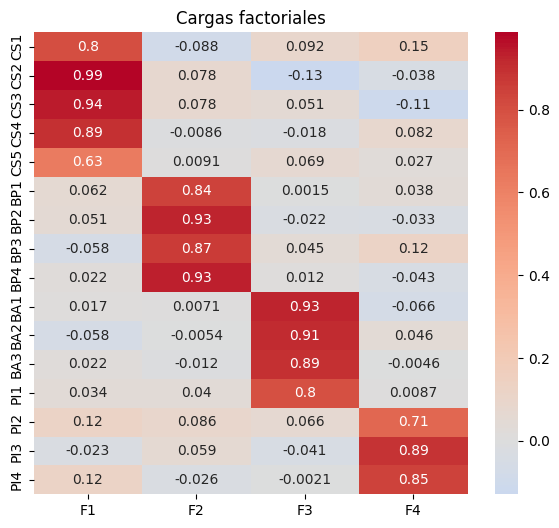

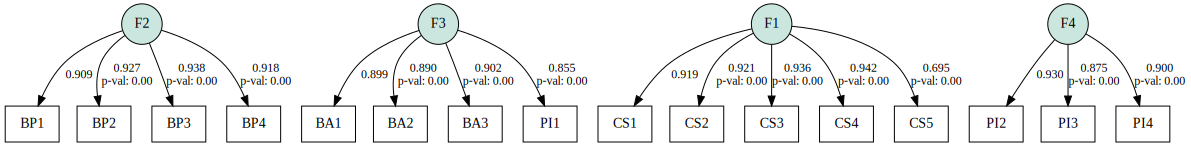

In [7]:
# Gráfico
!pip install factor_analyzer
!pip install semopy
from factor_analyzer import FactorAnalyzer
import seaborn as sns
import matplotlib.pyplot as plt

X_fa = marca.iloc[:, 3:].copy()

af = FactorAnalyzer(n_factors=4, rotation="promax", method="ml")
af.fit(X_fa)

cargas = pd.DataFrame(
    af.loadings_,
    index=X_fa.columns,
    columns=[f"F{i}" for i in range(1, 5)]
)

plt.figure(figsize=(7, 6))
sns.heatmap(cargas, annot=True, cmap="coolwarm", center=0)
plt.title("Cargas factoriales")
plt.show()

modelo = """
F1 =~ CS1 + CS2 + CS3 + CS4 + CS5
F2 =~ BP1 + BP2 + BP3 + BP4
F3 =~ BA1 + BA2 + BA3 + PI1
F4 =~ PI2 + PI3 + PI4
"""

from semopy import Model, semplot

ajuste = Model(modelo)
ajuste.fit(marca)

semplot(
    ajuste,
    "modelo_sem.png",
    std_ests=True,
    engine="dot",
    plot_covs=False
)

In [8]:
# Análisis Factorial Confirmatorio

# Modelo teórico
modelo = """
  CS =~ CS1 + CS2 + CS3 + CS4 + CS5
  BP =~ BP1 + BP2 + BP3 + BP4
  BA =~ BA1 + BA2 + BA3
  PI =~ PI1 + PI2 + PI3 + PI4
"""

# Ajuste del modelo
from semopy import Model
from semopy.stats import calc_stats

ajuste = Model(modelo)
ajuste.fit(marca)

display(ajuste.inspect(std_est=True))
display(calc_stats(ajuste).T.loc[["chi2", "chi2 p-value", "CFI", "TLI", "RMSEA"]])

# Chi-square test: idealmente no significativa
# Comparative Fit Index (CFI): > 0.95
# Tucker-Lewis Index (TLI): > 0.95
# Error cuadrático medio de aproximación (RMSEA): < 0.06
# Residuo estandarizado cuadrático medio (SRMR): < 0.08
# Latent Variables:
## Std.lv (Carga factorial estandarizada)
## Std.all (correlación entre el ítem y su factor)
# Covariances:
## Std.all: Correlación entre los factores latentes
# Variances:
## Std.all: Proporción de varianza no explicada por el factor

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,CS1,~,CS,1.000000,0.918672,-,-,-
1,CS2,~,CS,0.865721,0.920638,0.038478,22.498939,0.0
2,CS3,~,CS,0.940738,0.935627,0.039693,23.700575,0.0
3,CS4,~,CS,0.898175,0.942033,0.037041,24.248222,0.0
4,CS5,~,CS,0.786343,0.695078,0.06432,12.225508,0.0
5,BP1,~,BP,1.000000,0.908817,-,-,-
6,BP2,~,BP,1.039705,0.926620,0.04721,22.022778,0.0
7,BP3,~,BP,1.048692,0.938094,0.045919,22.837996,0.0
8,BP4,~,BP,1.022311,0.917473,0.047767,21.402144,0.0
9,BA1,~,BA,1.000000,0.902678,-,-,-


,Value
chi2,381.937914
chi2 p-value,0.000000
CFI,0.921106
TLI,0.903395
RMSEA,0.122207


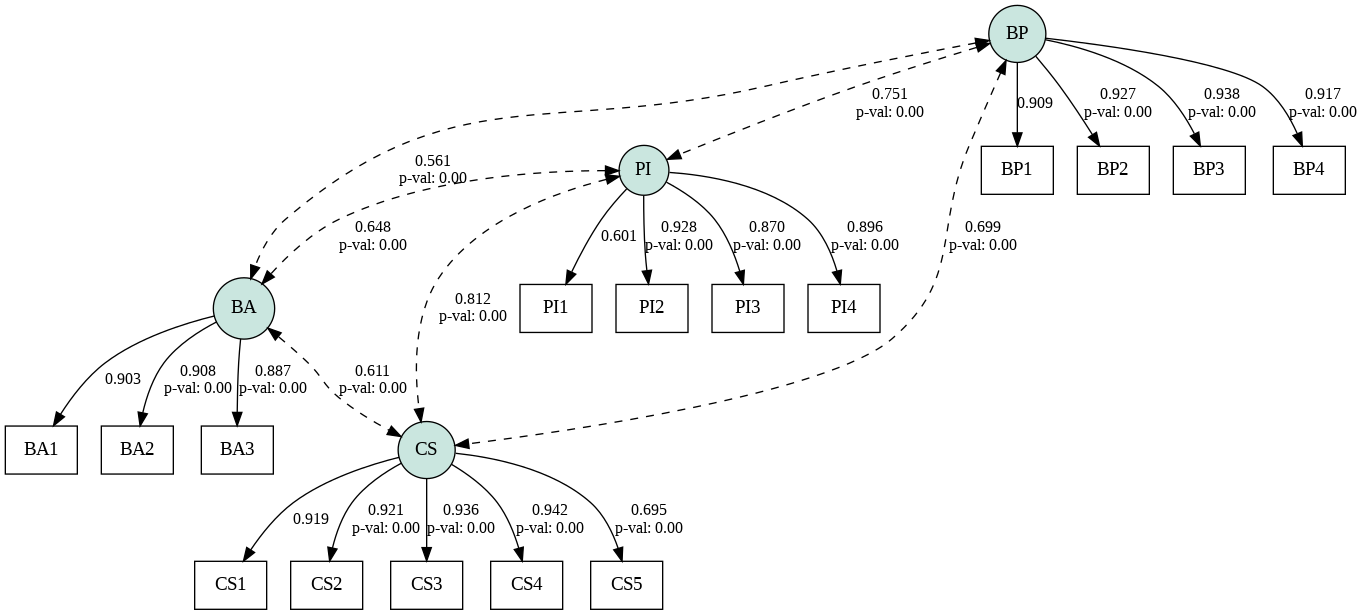

In [9]:
# Diagrama del modelo
!pip install graphviz

from semopy import semplot
from IPython.display import Image, display

g = semplot(
    ajuste,
    "modelo_afc.png",
    std_ests=True,
    engine="dot",
    plot_covs=True
)

display(Image(filename="modelo_afc.png"))